<a href="https://colab.research.google.com/github/immischein/ML-bandgap/blob/main/DNN_MAE_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install category_encoders
!pip install skorch
!pip install optuna
!pip install optuna-integration[skorch]
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.9/228.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 5.6 MB/s eta 0:00:00


# Imports

In [2]:
from google.colab import drive

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.preprocessing import OneHotEncoder

import category_encoders as ce

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from tqdm import tqdm

import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np

from skorch.helper import predefined_split
from skorch.dataset import Dataset
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import shap
import category_encoders as ce
import time



### Load Datasets

In [3]:
drive.mount('/content/drive')

# load original dataset (all materials)
df_full = pd.read_csv('/content/drive/MyDrive/Project Documents ML-CMT/bandgap_dataset_full.csv')

Mounted at /content/drive


### Data cleaning step

In [4]:
def initial_data_cleaning(df, target_col='band_gap', id_col='material_id', corr_thresh=0.95):
    df = df.copy()

    # Drop identifier
    if id_col in df.columns:
        df = df.drop(columns=id_col)

    # Separate target
    X = df.drop(columns=target_col)
    y = df[target_col]

    # Split first (to avoid leakage)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Drop columns with >65% missing
    missing_frac = X_train.isnull().mean()
    drop_cols = missing_frac[missing_frac > 0.65].index.tolist()
    print(f"Dropping columns with >65% missing values: {drop_cols}")
    X_train = X_train.drop(columns=drop_cols)
    X_test = X_test.drop(columns=drop_cols)

    # Correlation-based feature dropping (on train set only)
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = []
    for col in upper.columns:
        for row in upper.index:
            if upper.loc[row, col] > corr_thresh:
                if row in to_drop or col in to_drop:
                    continue
                target_corr = X_train.corrwith(y_train)
                drop = row if target_corr[row] < target_corr[col] else col
                to_drop.append(drop)

    print(f"Dropping correlated features: {to_drop}")
    X_train = X_train.drop(columns=to_drop)
    X_test = X_test.drop(columns=to_drop)

    return X_train, X_test, y_train, y_test

### Preprocessing Pipeline

In [5]:
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, column):
        self.column = column  # ✅ declared here, not in fit
        self.encoder_ = None  # ✅ trailing underscore: fitted object

    def fit(self, X, y):
        self.encoder_ = ce.TargetEncoder(cols=[self.column])
        self.encoder_.fit(X, y)
        return self

    def transform(self, X):
        return self.encoder_.transform(X)

            # Add this method to provide output feature names
    def get_feature_names_out(self, input_features=None):
        # The output feature name is the same as the input column name
        # Target encoding typically replaces the column in place
        return [self.column]


In [6]:
def build_preprocessor(numeric_cols, nonnumeric_cols, te_col='spacegroup_number '):
    if te_col in numeric_cols:
        numeric_cols = [col for col in numeric_cols if col != te_col]

    num_pipeline = make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler()
    )

    # cat_pipeline = make_pipeline(TargetEncoderWrapper())
    cat_pipeline = make_pipeline(TargetEncoderWrapper(column='spacegroup_number '))

    nonnumeric_pipeline = make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore")
    )

    preprocessor = make_column_transformer(
        (num_pipeline, numeric_cols),
        (cat_pipeline, [te_col]),
        (nonnumeric_pipeline, nonnumeric_cols)
    )

    return preprocessor


### Evaluation Pipeline

In [7]:
def run_final_test_evaluation(X_train, X_test, y_train, y_test, model_dict):
    final_results = []
    trained_pipelines = []

    # Detect column types
    te_col = 'spacegroup_number '
    numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    nonnumeric_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

    # Remove target-encoded column from numeric
    if te_col in numeric_cols:
        numeric_cols.remove(te_col)

    for name, model in model_dict.items():
        print(f"\nTraining final model: {name}")

        # Build preprocessor and pipeline
        preprocessor = build_preprocessor(numeric_cols, nonnumeric_cols, te_col=te_col)
        pipeline = make_pipeline(preprocessor, model)

        # Fit on full training set
        pipeline.fit(X_train, y_train)

        # Evaluate on test set
        y_pred = pipeline.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse_ = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        final_results.append({
            'Model': name,
            'Test MAE': mae,
            'Test RMSE': rmse_,
            'Test R²': r2
        })

        trained_pipelines.append((name, pipeline))

    return pd.DataFrame(final_results), dict(trained_pipelines)


# Manual Testing

In [8]:
# Clean data
X_train_full, X_test_full, y_train_full, y_test_full = initial_data_cleaning(df_full, target_col='band_gap')

Dropping columns with >65% missing values: []
Dropping correlated features: ['mean_distance', 'std_distance', 'std_am_weighted', 'std_vdw_weighted', 'std_molar_volume_weighted', 'electron_affinity_range_weighted', 'en_range', 'max_en ', 'avg_en', 'std_en', 'ie_range', 'max_ie ', 'min_ie', 'avg_am', 'am_range', 'max_am ', 'vdw_range', 'avg_vdw', 'max_vdw ', 'min_vdw', 'std_molar_volume', 'max_molar_volume ', 'electron_affinity_range', 'std_electron_affinity', 'avg_electronegativity', 'electronegativity_range', 'std_electronegativity', 'max_electronegativity ', 'min_electronegativity', 'atomic_radius_range', 'max_atomic_radius ', 'boiling_point_range', 'avg_boiling_point', 'max_boiling_point ']


In [9]:
# Make a copy of X_train_full
X_train = X_train_full.copy()
y_train = y_train_full.copy()

# Make a copy of X_test_full
X_test = X_test_full.copy()
y_test = y_test_full.copy()

## Preprocsss

In [10]:
te_col = 'spacegroup_number '
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
nonnumeric_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

if te_col in numeric_cols:
    numeric_cols.remove(te_col)

preprocessor = build_preprocessor(numeric_cols, nonnumeric_cols, te_col)
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

## Using Specified Models

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "MLP": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True, random_state=42),
    "Random Forest (Optuna)" : RandomForestRegressor(
    random_state=42,
    n_estimators=800, # number of trees
    max_depth=39, # maximum depth of the individual trees is unlimited
    min_samples_leaf=1, # minimum number of samples required to be at a leaf node
    min_samples_split=2, # minimum number of samples required to split an internal node
    max_features='sqrt', # number of features to consider when looking for the best split
    n_jobs=-1
    )
}

## Model Evaluation


5-Fold Cross-Validated Test Set Performance:
Linear Regression: MAE = 1.043, R² = 0.289
Random Forest: MAE = 0.667, R² = 0.637
MLP: MAE = 0.786, R² = 0.544
Random Forest (Optuna): MAE = 0.678, R² = 0.633


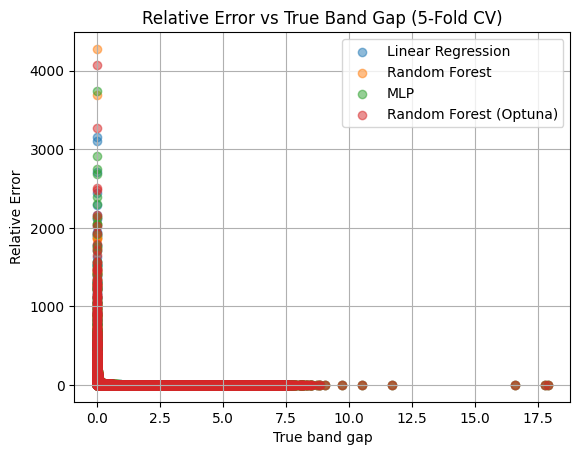

In [14]:
from sklearn.model_selection import KFold, cross_val_predict

results = {}
print("\n5-Fold Cross-Validated Test Set Performance:")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
   pipeline = make_pipeline(preprocessor, model)
   y_pred = cross_val_predict(pipeline, X_train, y_train, cv=kf)
   mae = mean_absolute_error(y_train, y_pred)
   r2 = r2_score(y_train, y_pred)
   results[name] = {"mae": mae, "r2": r2}

   print(f"{name}: MAE = {mae:.3f}, R² = {r2:.3f}")

   relative_error = np.abs(y_pred - y_train) / y_train
   plt.scatter(y_train, relative_error, label=name, alpha=0.5)

plt.xlabel("True band gap")
plt.ylabel("Relative Error")
plt.title("Relative Error vs True Band Gap (5-Fold CV)")
plt.legend()
plt.grid(True)
plt.show()

## Testing Deep Neural Networks

In [15]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_processed.toarray()
                              if hasattr(X_train_processed, "toarray")
                              else X_train_processed, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_processed.toarray()
                             if hasattr(X_test_processed, "toarray")
                             else X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_full.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_full.values, dtype=torch.float32).view(-1, 1)

In [16]:
# Define model
class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)

        )

    def forward(self, x):

        return self.net(x)

model_layers3 = DeepRegressor(X_train_tensor.shape[1])


### Run the model on GPU if available

In [17]:
# Put the model on the GPU if available
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers3.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


### Define the training loop

In [18]:
import time
from tqdm import trange
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(
    model,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=10,
    batch_size=64,
):
    """
    Trains a PyTorch regression model with early stopping and learning rate scheduling.

    Returns:
        model: The trained model with best weights
        train_losses: List of training loss per epoch
        test_losses: List of test loss per epoch
    """
    # Create DataLoader for training
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Setup
    start_time = time.time()
    criterion = nn.MSELoss()  # Mean squared error loss for regression
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)  # Adam optimizer
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience
    )  # Reduce LR on plateau

    train_losses = []
    test_losses = []
    best_loss = float('inf')
    trigger_times = 0

    for epoch in trange(n_epochs, desc="Training"):
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(X_train_tensor)  # Forward pass on train set
        loss = criterion(y_pred_train, y_train_tensor)  # Compute train loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test_tensor)  # Forward pass on test set
            test_loss = criterion(y_pred_test, y_test_tensor)  # Compute test loss

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        scheduler.step(test_loss.item())  # Step the LR scheduler

        # Early stopping logic
        if test_loss.item() < best_loss:
            best_loss = test_loss.item()
            best_model_state = model.state_dict()  # Save best model weights
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= early_stop_patience:
                print(f"\n⏹️ Early stopping at epoch {epoch}")
                break
        if epoch % verbose_every == 0:
            print(f"Epoch {epoch:4d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

    # Restore best model weights after training
    model.load_state_dict(best_model_state)

    # Report training time
    end_time = time.time()
    duration = end_time - start_time
    print(f"\n✅ Training completed in {duration:.2f} seconds ({duration / 60:.2f} minutes)")

    return model, train_losses, test_losses


### Train the Model

In [19]:
model_layers3, train_losses_layers3, test_losses_layers3 = train_model(
    model_layers3,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   1%|          | 50/5000 [00:00<00:54, 90.62it/s]

Epoch    0 | Train Loss: 6.6494 | Test Loss: 6.2565
Epoch   20 | Train Loss: 2.3653 | Test Loss: 2.3786
Epoch   40 | Train Loss: 1.9909 | Test Loss: 1.9863
Epoch   60 | Train Loss: 1.8485 | Test Loss: 1.8532
Epoch   80 | Train Loss: 1.7706 | Test Loss: 1.7779


Training:   4%|▍         | 214/5000 [00:01<00:14, 337.44it/s]

Epoch  100 | Train Loss: 1.7092 | Test Loss: 1.7165
Epoch  120 | Train Loss: 1.6520 | Test Loss: 1.6606
Epoch  140 | Train Loss: 1.5988 | Test Loss: 1.6094
Epoch  160 | Train Loss: 1.5524 | Test Loss: 1.5640
Epoch  180 | Train Loss: 1.5110 | Test Loss: 1.5234
Epoch  200 | Train Loss: 1.4744 | Test Loss: 1.4875


Training:   7%|▋         | 326/5000 [00:01<00:10, 439.00it/s]

...

Epoch 2260 | Train Loss: 0.8227 | Test Loss: 1.0642
Epoch 2280 | Train Loss: 0.8205 | Test Loss: 1.0628
Epoch 2300 | Train Loss: 0.8238 | Test Loss: 1.0676
Epoch 2320 | Train Loss: 0.8172 | Test Loss: 1.0621
Epoch 2340 | Train Loss: 0.8163 | Test Loss: 1.0627
Epoch 2360 | Train Loss: 0.8160 | Test Loss: 1.0646


Training:  50%|████▉     | 2476/5000 [00:04<00:04, 580.22it/s]

Epoch 2380 | Train Loss: 0.8160 | Test Loss: 1.0640
Epoch 2400 | Train Loss: 0.8130 | Test Loss: 1.0634
Epoch 2420 | Train Loss: 0.8111 | Test Loss: 1.0629
Epoch 2440 | Train Loss: 0.8101 | Test Loss: 1.0622
Epoch 2460 | Train Loss: 0.8093 | Test Loss: 1.0622
Epoch 2480 | Train Loss: 0.8088 | Test Loss: 1.0622


Training:  51%|█████▏    | 2572/5000 [00:05<00:04, 497.98it/s]

Epoch 2500 | Train Loss: 0.8085 | Test Loss: 1.0623
Epoch 2520 | Train Loss: 0.8082 | Test Loss: 1.0623
Epoch 2540 | Train Loss: 0.8080 | Test Loss: 1.0623
Epoch 2560 | Train Loss: 0.8079 | Test Loss: 1.0623

⏹️ Early stopping at epoch 2572

✅ Training completed in 9.69 seconds (0.16 minutes)


### Evaluate the model

In [20]:
# Model evaluation
def evaluate_model(model, X_train_tensor, y_train, X_test_tensor, y_test, y_train_tensor=None):
    """
    Evaluates a trained PyTorch regression model on both training and test sets.

    Returns:
        Dictionary of metrics (MAE, RMSE, R²) for train and test sets
    """
    model.eval()

    with torch.no_grad():
        y_pred_test = model(X_test_tensor).detach().cpu().numpy()
        y_pred_train = model(X_train_tensor).detach().cpu().numpy()


    # Evaluate on test set
    mae_test = mean_absolute_error(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Evaluate on train set
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_pred_train)

    return {
        "test": {"MAE": mae_test, "RMSE": rmse_test, "R2": r2_test, "y_pred_test": y_pred_test},
        "train": {"MAE": mae_train, "RMSE": rmse_train, "R2": r2_train, "y_pred_train": y_pred_train}
    }

### Analyze the model

In [21]:
# Plot learning curves
import matplotlib.pyplot as plt

def analyze_model(metrics, y_test,
                  train_losses, test_losses, model_name="PyTorch Model"):
    """
    Plots learning curves, prints metrics, and plots predicted vs. true values.
    """

    # 2. Plot learning curves
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"{model_name} Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Print metrics
    print(f"[{model_name} - Test Set]")
    print(f"MAE:  {metrics['test']['MAE']:.4f}")
    print(f"RMSE: {metrics['test']['RMSE']:.4f}")
    print(f"R²:   {metrics['test']['R2']:.4f}")
    print(f"\n[{model_name} - Training Set]")
    print(f"MAE:  {metrics['train']['MAE']:.4f}")
    print(f"RMSE: {metrics['train']['RMSE']:.4f}")
    print(f"R²:   {metrics['train']['R2']:.4f}")

    # 4. Plot predicted vs true values (test set)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, metrics['test']['y_pred_test'], alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel("True Band Gap")
    plt.ylabel("Predicted Band Gap")
    plt.title(f"{model_name} - Predicted vs True (Test Set)")
    plt.grid(True)
    plt.show()


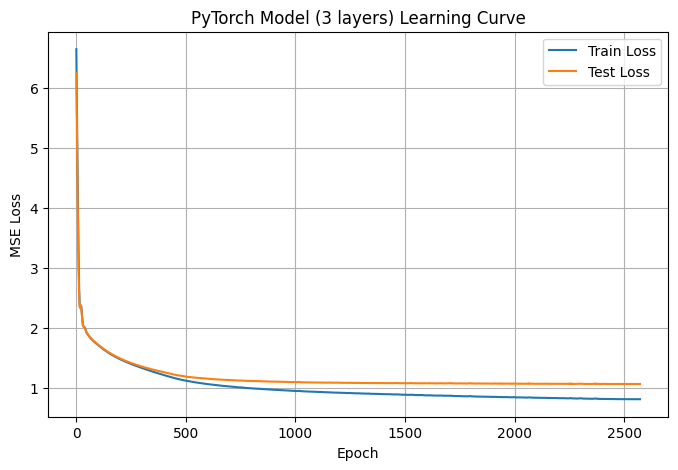

[PyTorch Model (3 layers) - Test Set]
MAE:  0.7651
RMSE: 1.0307
R²:   0.5599

[PyTorch Model (3 layers) - Training Set]
MAE:  0.6741
RMSE: 0.8988
R²:   0.6660


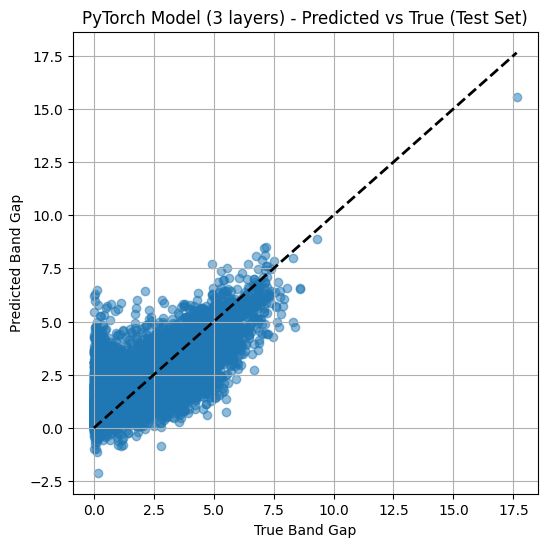

In [22]:
# Make a metrics dictionary
model_layers3_metrics = evaluate_model(
    model_layers3,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers3_metrics,
    y_test,
    train_losses_layers3,
    test_losses_layers3,
    model_name="PyTorch Model (3 layers)"
)

## 6 Layers Network

In [23]:
class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(  # Define the network layers
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)  # Output layer (no activation for regression)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the model with the input dimension (number of features)
model_layers6 = DeepRegressor(X_train_tensor.shape[1])

In [24]:

if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers6.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [25]:
model_layers6, train_losses_layers6, test_losses_layers6 = train_model(
    model_layers6,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   1%|          | 27/5000 [00:00<00:18, 269.37it/s]

Epoch    0 | Train Loss: 5.6735 | Test Loss: 5.5936
Epoch   20 | Train Loss: 2.4689 | Test Loss: 2.2990
Epoch   40 | Train Loss: 1.9857 | Test Loss: 1.9729


Training:   2%|▏         | 111/5000 [00:00<00:17, 274.03it/s]

Epoch   60 | Train Loss: 1.8225 | Test Loss: 1.8211
Epoch   80 | Train Loss: 1.7215 | Test Loss: 1.7227
Epoch  100 | Train Loss: 1.6231 | Test Loss: 1.6273


Training:   3%|▎         | 167/5000 [00:00<00:17, 274.52it/s]

...

Epoch 1080 | Train Loss: 0.7461 | Test Loss: 1.0616
Epoch 1100 | Train Loss: 0.7444 | Test Loss: 1.0619
Epoch 1120 | Train Loss: 0.7426 | Test Loss: 1.0620


Training:  24%|██▎       | 1177/5000 [00:04<00:13, 278.54it/s]

Epoch 1140 | Train Loss: 0.7413 | Test Loss: 1.0622
Epoch 1160 | Train Loss: 0.7404 | Test Loss: 1.0623
Epoch 1180 | Train Loss: 0.7395 | Test Loss: 1.0624


Training:  24%|██▍       | 1224/5000 [00:04<00:13, 277.07it/s]

Epoch 1200 | Train Loss: 0.7390 | Test Loss: 1.0625
Epoch 1220 | Train Loss: 0.7385 | Test Loss: 1.0626

⏹️ Early stopping at epoch 1224

✅ Training completed in 4.42 seconds (0.07 minutes)


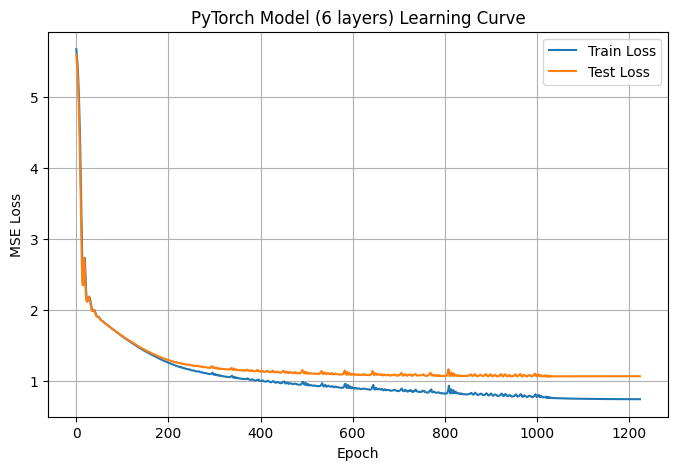

[PyTorch Model (6 layers) - Test Set]
MAE:  0.7561
RMSE: 1.0309
R²:   0.5598

[PyTorch Model (6 layers) - Training Set]
MAE:  0.6392
RMSE: 0.8593
R²:   0.6947


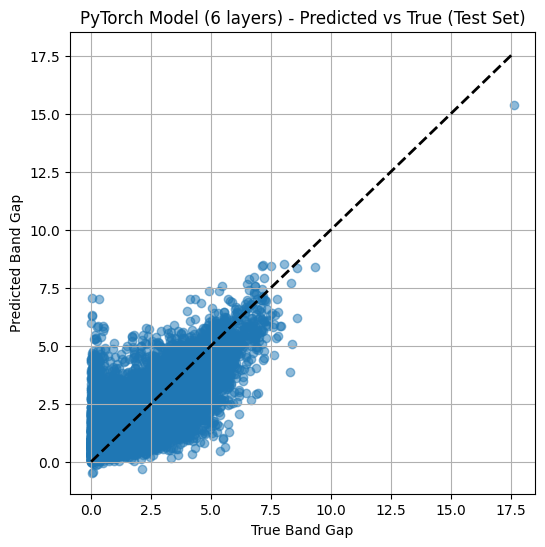

In [26]:
# Make a metrics dictionary
model_layers6_metrics = evaluate_model(
    model_layers6,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers6_metrics,
    y_test,
    train_losses_layers6,
    test_losses_layers6,
    model_name="PyTorch Model (6 layers)"
)

## 8 Layers Network

In [27]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),  # Layer 1
            nn.ReLU(),

            nn.Linear(512, 384),        # Layer 2
            nn.ReLU(),

            nn.Linear(384, 256),        # Layer 3
            nn.ReLU(),

            nn.Linear(256, 192),        # Layer 4
            nn.ReLU(),

            nn.Linear(192, 128),        # Layer 5
            nn.ReLU(),

            nn.Linear(128, 96),         # Layer 6
            nn.ReLU(),

            nn.Linear(96, 64),          # Layer 7
            nn.ReLU(),

            nn.Linear(64, 32),          # Layer 8
            nn.ReLU(),

            nn.Linear(32, 1)            # Output Layer
        )

    def forward(self, x):
        return self.net(x)

# Initialize the model with the input dimension (number of features)
model_layers8 = DeepRegressor(X_train_tensor.shape[1])

In [28]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers8.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [29]:
model_layers8, train_losses_layers8, test_losses_layers8 = train_model(
    model_layers8,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 7/5000 [00:00<01:12, 69.23it/s]

Epoch    0 | Train Loss: 6.1436 | Test Loss: 6.1031


Training:   1%|          | 28/5000 [00:00<01:11, 69.67it/s]

Epoch   20 | Train Loss: 2.4815 | Test Loss: 2.5528


Training:   1%|          | 49/5000 [00:00<01:11, 69.66it/s]

...

Epoch  840 | Train Loss: 0.4704 | Test Loss: 1.0401


Training:  17%|█▋        | 869/5000 [00:12<00:59, 69.26it/s]

Epoch  860 | Train Loss: 0.4635 | Test Loss: 1.0427


Training:  18%|█▊        | 891/5000 [00:12<00:59, 69.34it/s]

Epoch  880 | Train Loss: 0.4579 | Test Loss: 1.0448

⏹️ Early stopping at epoch 891

✅ Training completed in 12.85 seconds (0.21 minutes)


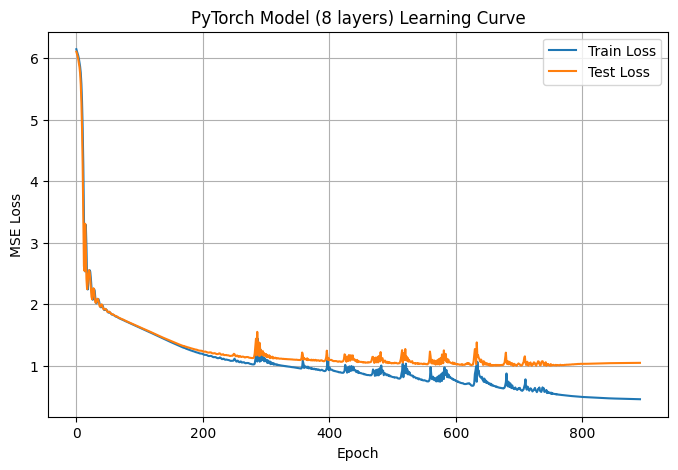

[PyTorch Model (8 layers) - Test Set]
MAE:  0.7302
RMSE: 1.0227
R²:   0.5667

[PyTorch Model (8 layers) - Training Set]
MAE:  0.4852
RMSE: 0.6742
R²:   0.8121


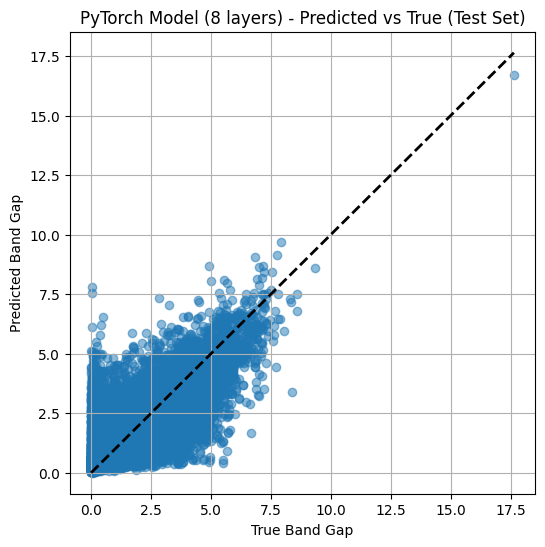

In [30]:
# Evaluate model
# Make a metrics dictionary
model_layers8_metrics = evaluate_model(
    model_layers8,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers8_metrics,
    y_test,
    train_losses_layers8,
    test_losses_layers8,
    model_name="PyTorch Model (8 layers)"
)

## 10 Layers Network

In [31]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),  # Layer 1
            nn.ReLU(),

            nn.Linear(512, 384),        # Layer 2
            nn.ReLU(),

            nn.Linear(384, 256),        # Layer 3
            nn.ReLU(),

            nn.Linear(256, 192),        # Layer 4
            nn.ReLU(),

            nn.Linear(192, 128),        # Layer 5
            nn.ReLU(),

            nn.Linear(128, 96),         # Layer 6
            nn.ReLU(),

            nn.Linear(96, 64),          # Layer 7
            nn.ReLU(),

            nn.Linear(64, 48),          # Layer 8
            nn.ReLU(),

            nn.Linear(48, 32),          # Layer 9
            nn.ReLU(),

            nn.Linear(32, 1)            # Layer 10 (Output)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the model
model_layers10 = DeepRegressor(X_train_tensor.shape[1])


In [32]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers10.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [33]:
model_layers10, train_losses_layers10, test_losses_layers10 = train_model(
    model_layers10,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 7/5000 [00:00<01:15, 65.99it/s]

Epoch    0 | Train Loss: 6.9341 | Test Loss: 6.8881


Training:   1%|          | 28/5000 [00:00<01:15, 66.07it/s]

Epoch   20 | Train Loss: 2.5695 | Test Loss: 2.6732


Training:   1%|          | 49/5000 [00:00<01:15, 65.97it/s]

...

Epoch  880 | Train Loss: 0.4945 | Test Loss: 1.0418


Training:  18%|█▊        | 910/5000 [00:13<01:02, 65.89it/s]

Epoch  900 | Train Loss: 0.4898 | Test Loss: 1.0440


Training:  18%|█▊        | 919/5000 [00:13<01:02, 65.77it/s]


⏹️ Early stopping at epoch 919

✅ Training completed in 13.98 seconds (0.23 minutes)


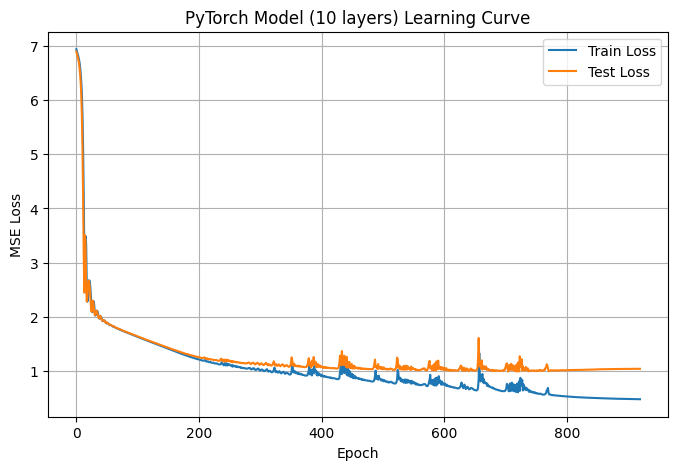

[PyTorch Model (10 layers) - Test Set]
MAE:  0.7323
RMSE: 1.0228
R²:   0.5666

[PyTorch Model (10 layers) - Training Set]
MAE:  0.4988
RMSE: 0.6965
R²:   0.7994


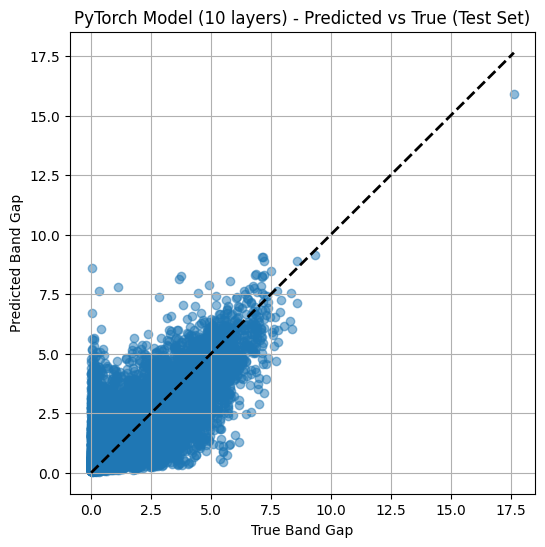

In [34]:
# Evaluate model
# Make a metrics dictionary
model_layers10_metrics = evaluate_model(
    model_layers10,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers10_metrics,
    y_test,
    train_losses_layers10,
    test_losses_layers10,
    model_name="PyTorch Model (10 layers)"
)


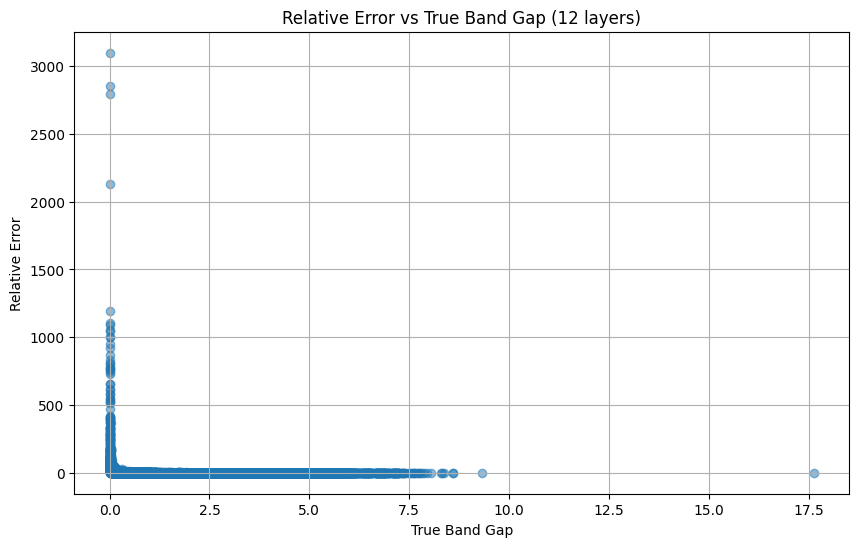

In [35]:
# relative error vs true band gap plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, np.abs(model_layers10_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5)
plt.xlabel("True Band Gap")
plt.ylabel("Relative Error")
plt.title("Relative Error vs True Band Gap (12 layers)")
plt.grid(True)
plt.show()

## 12 Layers Network

In [36]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 768),   # Layer 1
            nn.ReLU(),

            nn.Linear(768, 512),         # Layer 2
            nn.ReLU(),

            nn.Linear(512, 384),         # Layer 3
            nn.ReLU(),

            nn.Linear(384, 256),         # Layer 4
            nn.ReLU(),

            nn.Linear(256, 192),         # Layer 5
            nn.ReLU(),

            nn.Linear(192, 128),         # Layer 6
            nn.ReLU(),

            nn.Linear(128, 96),          # Layer 7
            nn.ReLU(),

            nn.Linear(96, 72),           # Layer 8
            nn.ReLU(),

            nn.Linear(72, 48),           # Layer 9
            nn.ReLU(),

            nn.Linear(48, 32),           # Layer 10
            nn.ReLU(),

            nn.Linear(32, 16),           # Layer 11
            nn.ReLU(),

            nn.Linear(16, 1)             # Layer 12 (Output)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the 12-layer model
model_layers12 = DeepRegressor(X_train_tensor.shape[1])


In [37]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers12.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [38]:
model_layers12, train_losses_layers12, test_losses_layers12 = train_model(
    model_layers12,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0, # L2 regularization
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 4/5000 [00:00<02:12, 37.77it/s]

Epoch    0 | Train Loss: 6.7143 | Test Loss: 6.6762


Training:   1%|          | 28/5000 [00:00<02:09, 38.26it/s]

Epoch   20 | Train Loss: 2.3951 | Test Loss: 2.6508


Training:   1%|          | 48/5000 [00:01<02:09, 38.30it/s]

...

Epoch  860 | Train Loss: 0.5111 | Test Loss: 1.0205


Training:  18%|█▊        | 888/5000 [00:23<01:47, 38.30it/s]

Epoch  880 | Train Loss: 0.5072 | Test Loss: 1.0219


Training:  18%|█▊        | 893/5000 [00:23<01:47, 38.25it/s]


⏹️ Early stopping at epoch 893

✅ Training completed in 23.35 seconds (0.39 minutes)


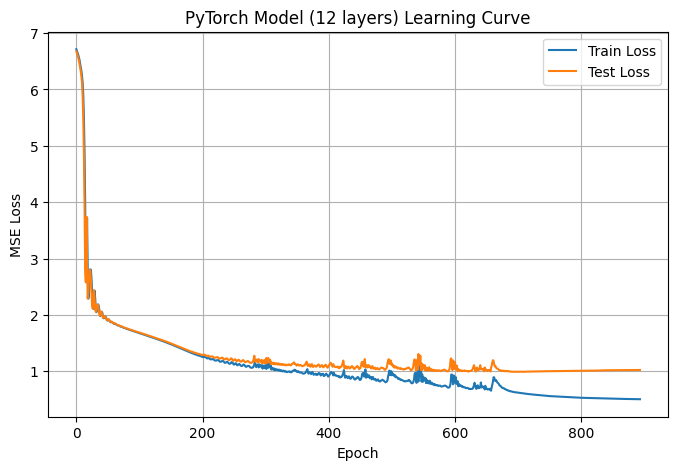

[PyTorch Model (12 layers) - Test Set]
MAE:  0.7246
RMSE: 1.0116
R²:   0.5761

[PyTorch Model (12 layers) - Training Set]
MAE:  0.5107
RMSE: 0.7102
R²:   0.7915


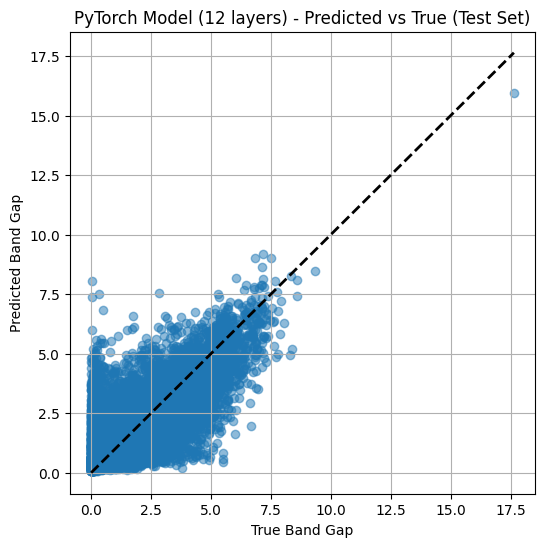

In [39]:
# Make a metrics dictionary
model_layers12_metrics = evaluate_model(
    model_layers12,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers12_metrics,
    y_test,
    train_losses_layers12,
    test_losses_layers12,
    model_name="PyTorch Model (12 layers)"
)

In [40]:
# shape of model_layers12_metrics['test']['y_pred_test']
print(model_layers12_metrics['test']['y_pred_test'].shape)
print(y_test.shape)

(16400, 1)
(16400,)


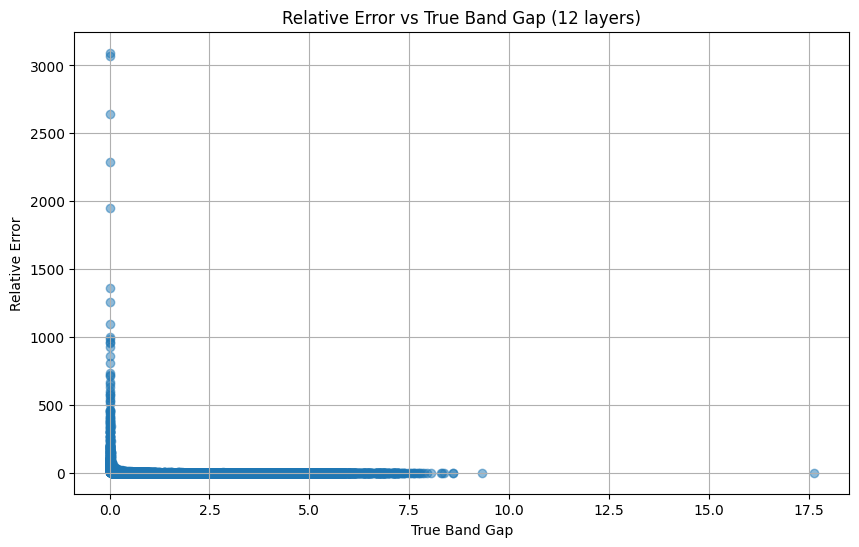

In [41]:
# relative error vs true band gap plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, np.abs(model_layers12_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5)
plt.xlabel("True Band Gap")
plt.ylabel("Relative Error")
plt.title("Relative Error vs True Band Gap (12 layers)")
plt.grid(True)
plt.show()

## 14 Layers Network

In [42]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 768),   # Layer 1
            nn.ReLU(),

            nn.Linear(768, 512),         # Layer 2
            nn.ReLU(),

            nn.Linear(512, 384),         # Layer 3
            nn.ReLU(),

            nn.Linear(384, 320),         # Layer 4
            nn.ReLU(),

            nn.Linear(320, 256),         # Layer 5
            nn.ReLU(),

            nn.Linear(256, 192),         # Layer 6
            nn.ReLU(),

            nn.Linear(192, 160),         # Layer 7
            nn.ReLU(),

            nn.Linear(160, 128),         # Layer 8
            nn.ReLU(),

            nn.Linear(128, 96),          # Layer 9
            nn.ReLU(),

            nn.Linear(96, 72),           # Layer 10
            nn.ReLU(),

            nn.Linear(72, 48),           # Layer 11
            nn.ReLU(),

            nn.Linear(48, 32),           # Layer 12
            nn.ReLU(),

            nn.Linear(32, 16),           # Layer 13
            nn.ReLU(),

            nn.Linear(16, 1)             # Layer 14 (Output)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the 14-layer model
model_layers14 = DeepRegressor(X_train_tensor.shape[1])

In [43]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers14.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [44]:
model_layers14, train_losses_layers14, test_losses_layers14 = train_model(
    model_layers14,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0, # L2 regularization
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 4/5000 [00:00<02:34, 32.27it/s]

Epoch    0 | Train Loss: 7.2083 | Test Loss: 7.1751


Training:   0%|          | 24/5000 [00:00<02:34, 32.20it/s]

Epoch   20 | Train Loss: 3.1902 | Test Loss: 3.0886


Training:   1%|          | 44/5000 [00:01<02:34, 32.16it/s]

...

Epoch 1020 | Train Loss: 0.4931 | Test Loss: 1.0405


Training:  21%|██        | 1044/5000 [00:32<02:02, 32.21it/s]

Epoch 1040 | Train Loss: 0.4897 | Test Loss: 1.0429


Training:  21%|██        | 1059/5000 [00:32<02:02, 32.18it/s]


⏹️ Early stopping at epoch 1059

✅ Training completed in 32.92 seconds (0.55 minutes)


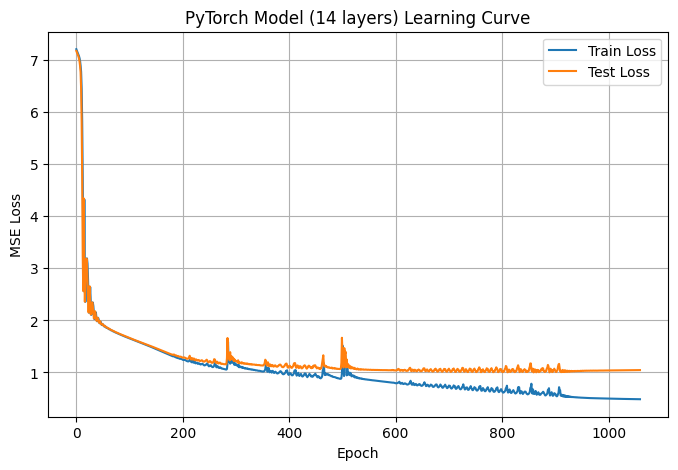

[PyTorch Model (14 layers) - Test Set]
MAE:  0.7335
RMSE: 1.0226
R²:   0.5668

[PyTorch Model (14 layers) - Training Set]
MAE:  0.5019
RMSE: 0.6971
R²:   0.7991


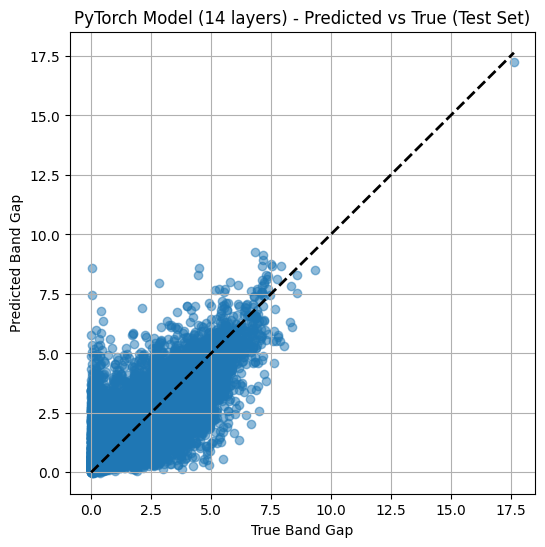

In [45]:
# Make a metrics dictionary
model_layers14_metrics = evaluate_model(
    model_layers14,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)

# Analyze the model
analyze_model(
    model_layers14_metrics,
    y_test,
    train_losses_layers14,
    test_losses_layers14,
    model_name="PyTorch Model (14 layers)"
)

## Adding Droppout

### 6 Layers

In [46]:
class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)  # Output layer (no activation for regression)
        )

    def forward(self, x):
        return self.net(x)
# Initialize the model with the input dimension (number of features)
model_layers6_dropout = DeepRegressor(X_train_tensor.shape[1])

In [47]:

if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers6_dropout.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [48]:
model_layers6_dropout, train_losses_layers6_dropout, test_losses_layers6_dropout = train_model(
    model_layers6_dropout,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 17/5000 [00:00<00:30, 163.71it/s]

Epoch    0 | Train Loss: 6.2572 | Test Loss: 6.1653
Epoch   20 | Train Loss: 2.7644 | Test Loss: 2.6922


Training:   1%|          | 41/5000 [00:00<00:24, 203.79it/s]

Epoch   40 | Train Loss: 2.0359 | Test Loss: 1.9877


Training:   1%|▏         | 64/5000 [00:00<00:22, 214.90it/s]

...

Epoch 1560 | Train Loss: 0.7746 | Test Loss: 0.9195
Epoch 1580 | Train Loss: 0.7772 | Test Loss: 0.9198


Training:  32%|███▏      | 1592/5000 [00:06<00:14, 235.50it/s]

Epoch 1600 | Train Loss: 0.7699 | Test Loss: 0.9197


Training:  32%|███▏      | 1620/5000 [00:06<00:14, 232.44it/s]


⏹️ Early stopping at epoch 1620

✅ Training completed in 6.97 seconds (0.12 minutes)


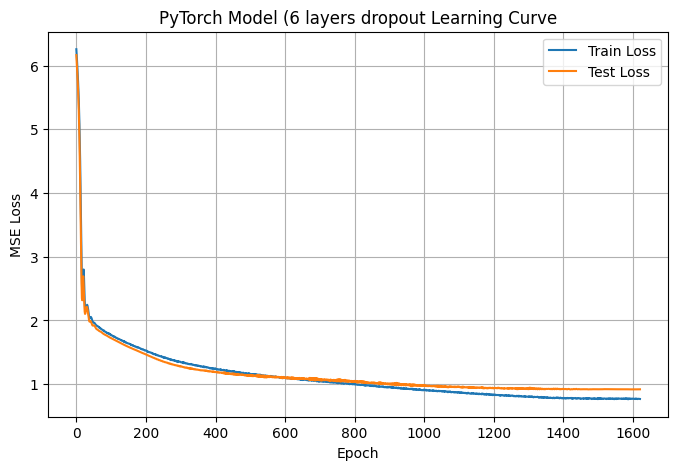

[PyTorch Model (6 layers dropout - Test Set]
MAE:  0.7080
RMSE: 0.9587
R²:   0.6192

[PyTorch Model (6 layers dropout - Training Set]
MAE:  0.5887
RMSE: 0.7746
R²:   0.7519


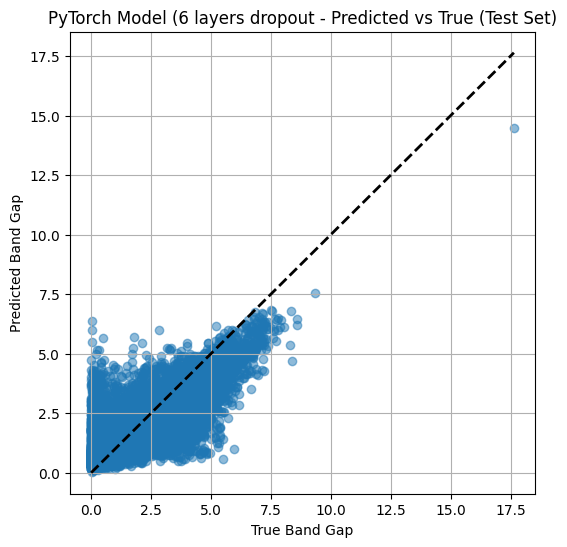

In [49]:
# Make a metrics dictionary
model_layers6_dropout_metrics = evaluate_model(
    model_layers6_dropout,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers6_dropout_metrics,
    y_test,
    train_losses_layers6_dropout,
    test_losses_layers6_dropout,
    model_name="PyTorch Model (6 layers dropout"
)

### 8 Layers

In [50]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 640),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(640, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 384),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(384, 256),
            nn.ReLU(),

            nn.Linear(256, 192),
            nn.ReLU(),

            nn.Linear(192, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # Output
        )

    def forward(self, x):
        return self.net(x)


In [51]:
# Initialize the 8-layer model
model_layers8_dropout = DeepRegressor(X_train_tensor.shape[1])

In [52]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers8_dropout.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [53]:
model_layers8_dropout, train_losses_layers8_dropout, test_losses_layers8_dropout = train_model(
    model_layers8_dropout,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 5/5000 [00:00<02:00, 41.34it/s]

Epoch    0 | Train Loss: 6.5955 | Test Loss: 6.5388


Training:   0%|          | 25/5000 [00:00<02:00, 41.20it/s]

Epoch   20 | Train Loss: 2.3532 | Test Loss: 2.4725


Training:   1%|          | 45/5000 [00:01<02:00, 41.24it/s]

...

Epoch  700 | Train Loss: 0.7973 | Test Loss: 0.9773


Training:  14%|█▍        | 725/5000 [00:17<01:43, 41.34it/s]

Epoch  720 | Train Loss: 0.7881 | Test Loss: 0.9728


Training:  15%|█▍        | 745/5000 [00:18<01:43, 41.23it/s]

Epoch  740 | Train Loss: 0.7902 | Test Loss: 0.9752

⏹️ Early stopping at epoch 745

✅ Training completed in 18.07 seconds (0.30 minutes)


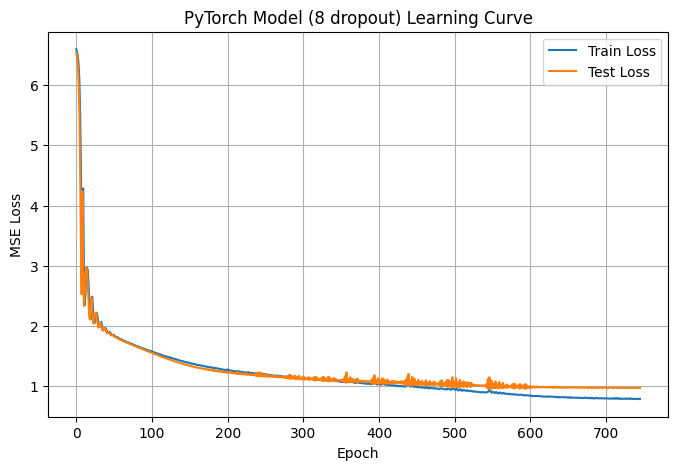

[PyTorch Model (8 dropout) - Test Set]
MAE:  0.7382
RMSE: 0.9853
R²:   0.5978

[PyTorch Model (8 dropout) - Training Set]
MAE:  0.6300
RMSE: 0.8258
R²:   0.7180


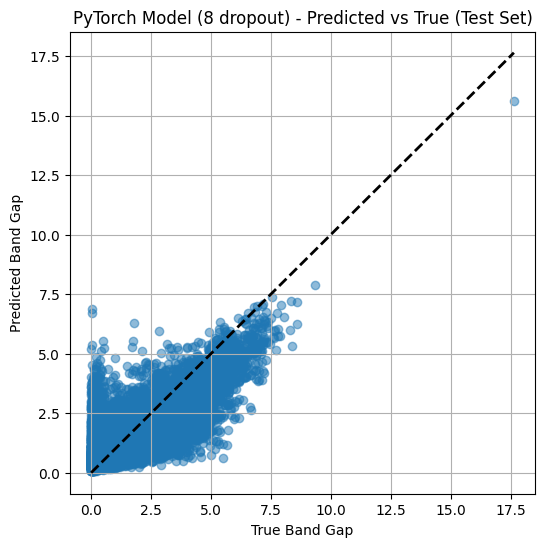

In [54]:
# Make a metrics dictionary
model_layers8_dropout_metrics = evaluate_model(
    model_layers8_dropout,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers8_dropout_metrics,
    y_test,
    train_losses_layers8_dropout,
    test_losses_layers8_dropout,
    model_name="PyTorch Model (8 dropout)"
)

### 10 Layers

In [55]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 384),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(256, 192),
            nn.ReLU(),

            nn.Linear(192, 128),
            nn.ReLU(),

            nn.Linear(128, 96),
            nn.ReLU(),

            nn.Linear(96, 64),
            nn.ReLU(),

            nn.Linear(64, 48),
            nn.ReLU(),

            nn.Linear(48, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


In [56]:
# Initialize the 10-layer model
model_layers10_dropout = DeepRegressor(X_train_tensor.shape[1])

In [57]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers10_dropout.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [58]:
model_layers10_dropout, train_losses_layers10_dropout, test_losses_layers10_dropout = train_model(
    model_layers10_dropout,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 7/5000 [00:00<01:21, 61.37it/s]

Epoch    0 | Train Loss: 6.3366 | Test Loss: 6.2899


Training:   1%|          | 28/5000 [00:00<01:20, 61.42it/s]

Epoch   20 | Train Loss: 2.5067 | Test Loss: 2.3080


Training:   1%|          | 49/5000 [00:00<01:20, 61.46it/s]

...

Epoch  580 | Train Loss: 0.9566 | Test Loss: 1.0395


Training:  12%|█▏        | 609/5000 [00:09<01:11, 61.51it/s]

Epoch  600 | Train Loss: 0.9475 | Test Loss: 1.0330


Training:  13%|█▎        | 627/5000 [00:10<01:11, 61.34it/s]

Epoch  620 | Train Loss: 0.9505 | Test Loss: 1.0361

⏹️ Early stopping at epoch 627

✅ Training completed in 10.22 seconds (0.17 minutes)


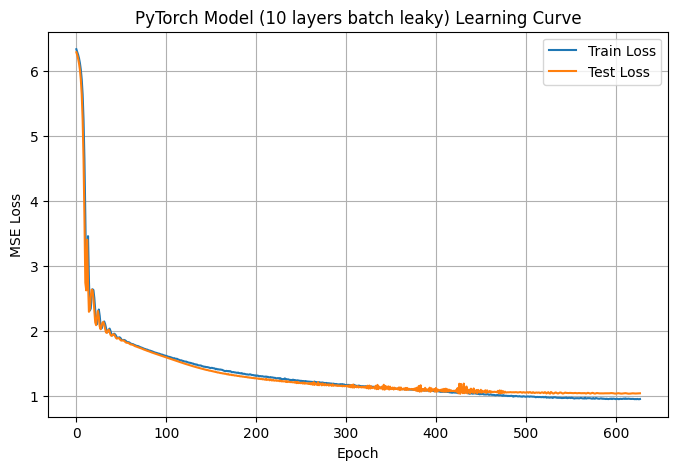

[PyTorch Model (10 layers batch leaky) - Test Set]
MAE:  0.7712
RMSE: 1.0186
R²:   0.5701

[PyTorch Model (10 layers batch leaky) - Training Set]
MAE:  0.7125
RMSE: 0.9304
R²:   0.6421


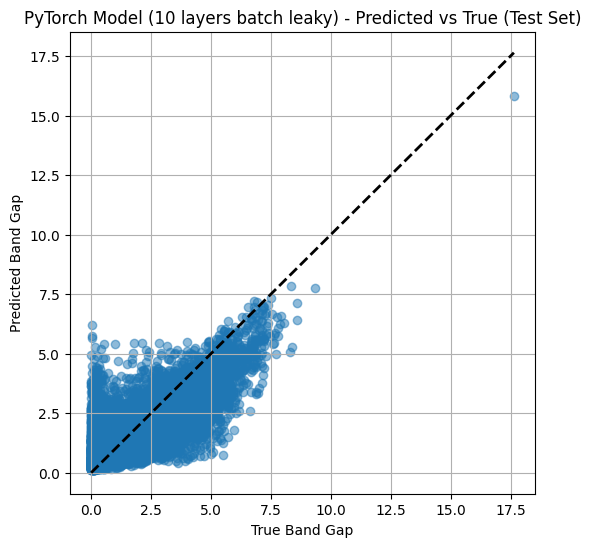

In [59]:
# Make a metrics dictionary
model_layers10_dropout_metrics = evaluate_model(
    model_layers10_dropout,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers10_dropout_metrics,
    y_test,
    train_losses_layers10_dropout,
    test_losses_layers10_dropout,
    model_name="PyTorch Model (10 layers batch leaky)"
)

## Adding Leaky Relu, batchnorm, and dropout

### 6 Layers

In [60]:
class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(),

            nn.Linear(16, 1)  # Output layer (no activation for regression)
        )

    def forward(self, x):
        return self.net(x)
# Initialize the model with the input dimension (number of features)
model_layers6_batch_leaky = DeepRegressor(X_train_tensor.shape[1])

In [61]:

if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers6_batch_leaky.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [62]:
model_layers6_batch_leaky, train_losses_layers6_batch_leaky, test_losses_layers6_batch_leaky = train_model(
    model_layers6_batch_leaky,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 3/5000 [00:00<02:48, 29.71it/s]

Epoch    0 | Train Loss: 5.6901 | Test Loss: 5.9350


Training:   0%|          | 23/5000 [00:00<00:39, 126.12it/s]

Epoch   20 | Train Loss: 4.0858 | Test Loss: 4.6598


Training:   1%|          | 43/5000 [00:00<00:31, 156.44it/s]

...

Epoch 1400 | Train Loss: 0.7276 | Test Loss: 0.8689


Training:  28%|██▊       | 1423/5000 [00:07<00:18, 196.67it/s]

Epoch 1420 | Train Loss: 0.7296 | Test Loss: 0.8694


Training:  29%|██▉       | 1452/5000 [00:07<00:18, 192.73it/s]

Epoch 1440 | Train Loss: 0.7300 | Test Loss: 0.8693

⏹️ Early stopping at epoch 1452

✅ Training completed in 7.54 seconds (0.13 minutes)


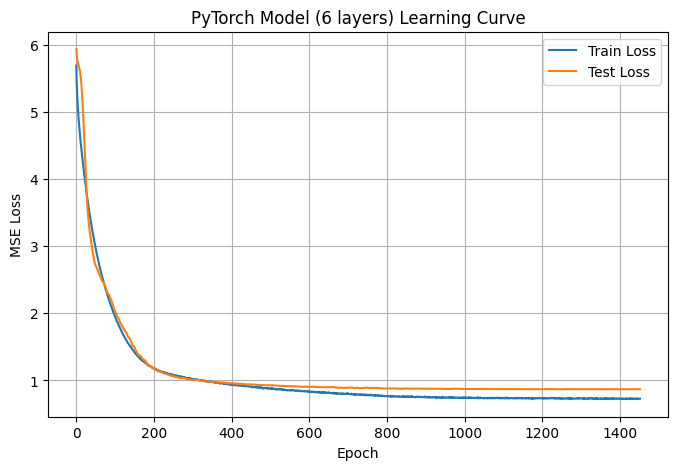

[PyTorch Model (6 layers) - Test Set]
MAE:  0.6708
RMSE: 0.9325
R²:   0.6398

[PyTorch Model (6 layers) - Training Set]
MAE:  0.5371
RMSE: 0.7150
R²:   0.7886


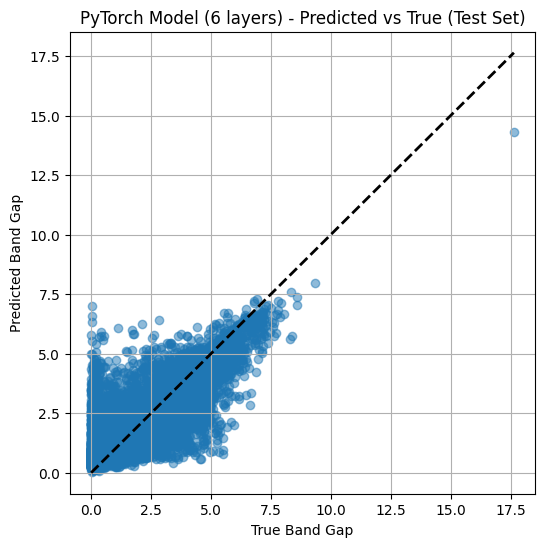

In [63]:
# Make a metrics dictionary
model_layers6_batch_leaky_metrics = evaluate_model(
    model_layers6_batch_leaky,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers6_batch_leaky_metrics,
    y_test,
    train_losses_layers6_batch_leaky,
    test_losses_layers6_batch_leaky,
    model_name="PyTorch Model (6 layers)"
)

### 8 Layers

In [64]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 640),
            nn.BatchNorm1d(640),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(640, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 384),
            nn.BatchNorm1d(384),
            nn.LeakyReLU(),
            nn.Dropout(0.15),

            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),

            nn.Linear(256, 192),
            nn.BatchNorm1d(192),
            nn.LeakyReLU(),

            nn.Linear(192, 128),
            nn.LeakyReLU(),

            nn.Linear(128, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 32),
            nn.LeakyReLU(),

            nn.Linear(32, 1)  # Output
        )

    def forward(self, x):
        return self.net(x)


In [65]:
# Initialize the 8-layer model
model_layers8_batch_leaky = DeepRegressor(X_train_tensor.shape[1])

In [66]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers8_batch_leaky.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [67]:
model_layers8_batch_leaky, train_losses_layers8_batch_leaky, test_losses_layers8_batch_leaky = train_model(
    model_layers8_batch_leaky,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 4/5000 [00:00<02:20, 35.43it/s]

Epoch    0 | Train Loss: 5.8824 | Test Loss: 5.8155


Training:   1%|          | 28/5000 [00:00<02:20, 35.37it/s]

Epoch   20 | Train Loss: 1.6232 | Test Loss: 1.5922


Training:   1%|          | 48/5000 [00:01<02:20, 35.34it/s]

...

Epoch  500 | Train Loss: 0.4948 | Test Loss: 0.8680


Training:  11%|█         | 528/5000 [00:14<02:05, 35.50it/s]

Epoch  520 | Train Loss: 0.4948 | Test Loss: 0.8696


Training:  11%|█         | 543/5000 [00:15<02:05, 35.47it/s]

Epoch  540 | Train Loss: 0.4951 | Test Loss: 0.8654

⏹️ Early stopping at epoch 543

✅ Training completed in 15.31 seconds (0.26 minutes)


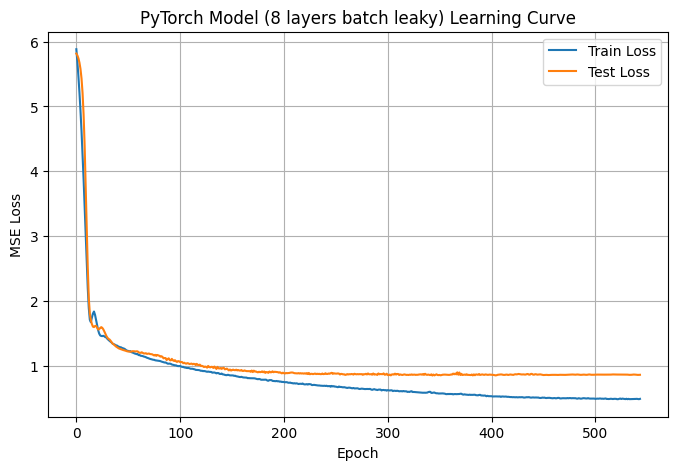

[PyTorch Model (8 layers batch leaky) - Test Set]
MAE:  0.6345
RMSE: 0.9304
R²:   0.6414

[PyTorch Model (8 layers batch leaky) - Training Set]
MAE:  0.3998
RMSE: 0.5457
R²:   0.8769


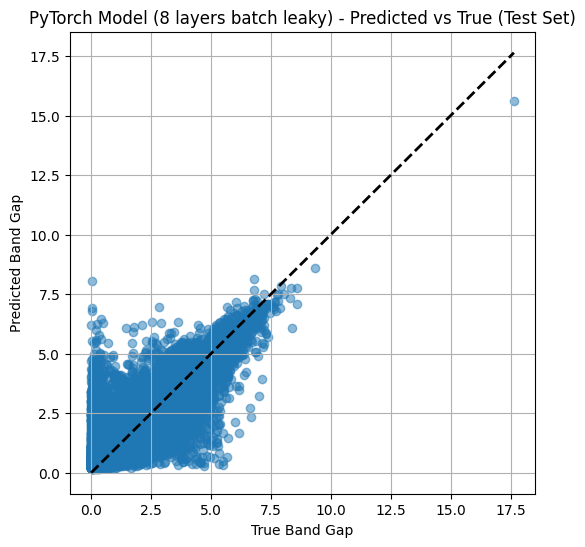

In [68]:
# Make a metrics dictionary
model_layers8_batch_leaky_metrics = evaluate_model(
    model_layers8_batch_leaky,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers8_batch_leaky_metrics,
    y_test,
    train_losses_layers8_batch_leaky,
    test_losses_layers8_batch_leaky,
    model_name="PyTorch Model (8 layers batch leaky)"
)

### 10 Layers

In [69]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 384),
            nn.BatchNorm1d(384),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.15),

            nn.Linear(256, 192),
            nn.BatchNorm1d(192),
            nn.LeakyReLU(),

            nn.Linear(192, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),

            nn.Linear(128, 96),
            nn.LeakyReLU(),

            nn.Linear(96, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 48),
            nn.LeakyReLU(),

            nn.Linear(48, 32),
            nn.LeakyReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


In [70]:
# Initialize the 10-layer model
model_layers10_batch_leaky = DeepRegressor(X_train_tensor.shape[1])

In [71]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers10_batch_leaky.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [72]:
model_layers10_batch_leaky, train_losses_layers10_batch_leaky, test_losses_layers10_batch_leaky = train_model(
    model_layers10_batch_leaky,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 6/5000 [00:00<01:35, 52.22it/s]

Epoch    0 | Train Loss: 6.1220 | Test Loss: 6.1122


Training:   1%|          | 30/5000 [00:00<01:35, 52.21it/s]

Epoch   20 | Train Loss: 1.8940 | Test Loss: 1.7398


Training:   1%|          | 48/5000 [00:00<01:34, 52.15it/s]

...

Epoch  540 | Train Loss: 0.5738 | Test Loss: 0.8791


Training:  11%|█▏        | 570/5000 [00:10<01:24, 52.49it/s]

Epoch  560 | Train Loss: 0.5706 | Test Loss: 0.8777


Training:  12%|█▏        | 582/5000 [00:11<01:24, 52.32it/s]

Epoch  580 | Train Loss: 0.5696 | Test Loss: 0.8777

⏹️ Early stopping at epoch 582

✅ Training completed in 11.13 seconds (0.19 minutes)


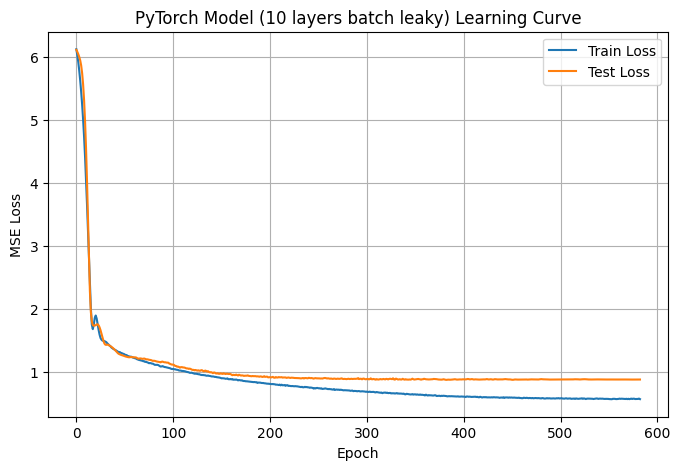

[PyTorch Model (10 layers batch leaky) - Test Set]
MAE:  0.6473
RMSE: 0.9368
R²:   0.6364

[PyTorch Model (10 layers batch leaky) - Training Set]
MAE:  0.4418
RMSE: 0.6018
R²:   0.8503


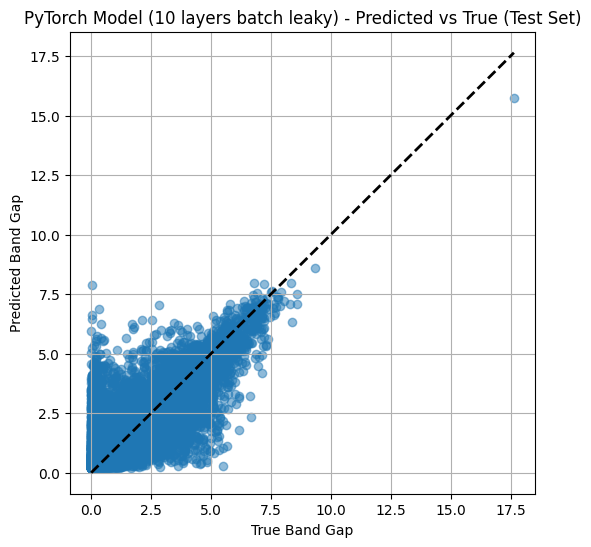

In [73]:
# Make a metrics dictionary
model_layers10_batch_leaky_metrics = evaluate_model(
    model_layers10_batch_leaky,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers10_batch_leaky_metrics,
    y_test,
    train_losses_layers10_batch_leaky,
    test_losses_layers10_batch_leaky,
    model_name="PyTorch Model (10 layers batch leaky)"
)

## Ensemble Predictions

In [74]:
def ensemble_predict(models, X_tensor):
    """
    Averages predictions from multiple models.

    Args:
        models (list): List of trained PyTorch models
        X_tensor (torch.Tensor): Input features

    Returns:
        np.ndarray: Averaged predictions (numpy array)
    """
    preds = []

    for model in models:
        model.eval()
        with torch.no_grad():
            pred = model(X_tensor).detach().cpu().numpy()
            preds.append(pred)

    # Stack and average predictions
    preds = np.stack(preds, axis=0)  # Shape: (num_models, num_samples, 1)
    avg_preds = np.mean(preds, axis=0)  # Shape: (num_samples, 1)

    return avg_preds


In [75]:
# Assume you have 3 trained models
# models["Random Forest"].fit(X_train_processed, y_train)
models = [model_layers6, model_layers10]

# Ensemble predictions on test data
ensemble_preds = ensemble_predict(models, X_test_tensor)

mae = mean_absolute_error(y_test, ensemble_preds)
rmse = mean_squared_error(y_test, ensemble_preds)
r2 = r2_score(y_test, ensemble_preds)

print(f"[Ensemble Results models 6 and 10 layers]")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

[Ensemble Results models 6 and 10 layers]
MAE:  0.7077
RMSE: 0.9535
R²:   0.6050


# Summary of all

In [76]:
# Print the summaries of all the models based on mae rmse and r2#
# summarize all model by mae and r2 values
print("\nSummary of all models:")
print(f"{'Model':<30} {'MAE':<10} {'RMSE':<10} {'R²':<10}")
for name, result in results.items():
    print(f"{name:<30} {result['mae']:<10.4f} {np.sqrt(result['mae']):<10.4f} {result['r2']:<10.4f}")

print(f"{'PyTorch 3-layers':<30} {model_layers3_metrics['test']['MAE']:<10.4f} {model_layers3_metrics['test']['RMSE']:<10.4f} {model_layers3_metrics['test']['R2']:<10.4f}")
# print(f"{'PyTorch 3-layers train':<30} {model_layers3_metrics['train']['MAE']:<10.4f} {model_layers3_metrics['train']['RMSE']:<10.4f} {model_layers3_metrics['train']['R2']:<10.4f}")
print(f"{'PyTorch 6-layers':<30} {model_layers6_metrics['test']['MAE']:<10.4f} {model_layers6_metrics['test']['RMSE']:<10.4f} {model_layers6_metrics['test']['R2']:<10.4f}")
# print(f"{'PyTorch 6-layers train':<30} {model_layers6_metrics['train']['MAE']:<10.4f} {model_layers6_metrics['train']['RMSE']:<10.4f} {model_layers6_metrics['train']['R2']:<10.4f}")
print(f"{'PyTorch 8-layers':<30} {model_layers8_metrics['test']['MAE']:<10.4f} {model_layers8_metrics['test']['RMSE']:<10.4f} {model_layers8_metrics['test']['R2']:<10.4f}")
print(f"{'PyTorch 10-layers':<30} {model_layers10_metrics['test']['MAE']:<10.4f} {model_layers10_metrics['test']['RMSE']:<10.4f} {model_layers10_metrics['test']['R2']:<10.4f}")
# print(f"{'PyTorch 10-layers train':<30} {model_layers10_metrics['train']['MAE']:<10.4f} {model_layers10_metrics['train']['RMSE']:<10.4f} {model_layers10_metrics['train']['R2']:<10.4f}")
print(f"{'PyTorch 12-layers':<30} {model_layers12_metrics['test']['MAE']:<10.4f} {model_layers12_metrics['test']['RMSE']:<10.4f} {model_layers12_metrics['test']['R2']:<10.4f}")
print(f"{'PyTorch 14-layers':<30} {model_layers14_metrics['test']['MAE']:<10.4f} {model_layers14_metrics['test']['RMSE']:<10.4f} {model_layers14_metrics['test']['R2']:<10.4f}")
print(f"{'Ensemble 6 and 10 layers':<30} {mae:<10.4f} {rmse:<10.4f} {r2:<10.4f}")

print(f"{'6-layers droppout':<30} {model_layers6_dropout_metrics['test']['MAE']:<10.4f} {model_layers6_dropout_metrics['test']['RMSE']:<10.4f} {model_layers6_dropout_metrics['test']['R2']:<10.4f}")
print(f"{'8-layers droppout':<30} {model_layers8_dropout_metrics['test']['MAE']:<10.4f} {model_layers8_dropout_metrics['test']['RMSE']:<10.4f} {model_layers8_dropout_metrics['test']['R2']:<10.4f}")
print(f"{'10-layers droppout':<30} {model_layers10_dropout_metrics['test']['MAE']:<10.4f} {model_layers10_dropout_metrics['test']['RMSE']:<10.4f} {model_layers10_dropout_metrics['test']['R2']:<10.4f}")

print(f"{'6-layers leaky relu, batch':<30} {model_layers6_batch_leaky_metrics['test']['MAE']:<10.4f} {model_layers6_batch_leaky_metrics['test']['RMSE']:<10.4f} {model_layers6_batch_leaky_metrics['test']['R2']:<10.4f}")
print(f"{'8-layers leaky relu, batch':<30} {model_layers8_batch_leaky_metrics['test']['MAE']:<10.4f} {model_layers8_batch_leaky_metrics['test']['RMSE']:<10.4f} {model_layers8_batch_leaky_metrics['test']['R2']:<10.4f}")
print(f"{'10-layers leaky relu, batch':<30} {model_layers10_batch_leaky_metrics['test']['MAE']:<10.4f} {model_layers10_batch_leaky_metrics['test']['RMSE']:<10.4f} {model_layers10_batch_leaky_metrics['test']['R2']:<10.4f}")


Summary of all models:
Model                          MAE        RMSE       R²        
Linear Regression              1.0429     1.0212     0.2890    
Random Forest                  0.6674     0.8169     0.6372    
MLP                            0.7859     0.8865     0.5444    
Random Forest (Optuna)         0.6781     0.8235     0.6326    
PyTorch 3-layers               0.7651     1.0307     0.5599    
PyTorch 6-layers               0.7561     1.0309     0.5598    
PyTorch 8-layers               0.7302     1.0227     0.5667    
PyTorch 10-layers              0.7323     1.0228     0.5666    
PyTorch 12-layers              0.7246     1.0116     0.5761    
PyTorch 14-layers              0.7335     1.0226     0.5668    
Ensemble 6 and 10 layers       0.7077     0.9535     0.6050    
6-layers droppout              0.7080     0.9587     0.6192    
8-layers droppout              0.7382     0.9853     0.5978    
10-layers droppout             0.7712     1.0186     0.5701    
6-layers leaky r

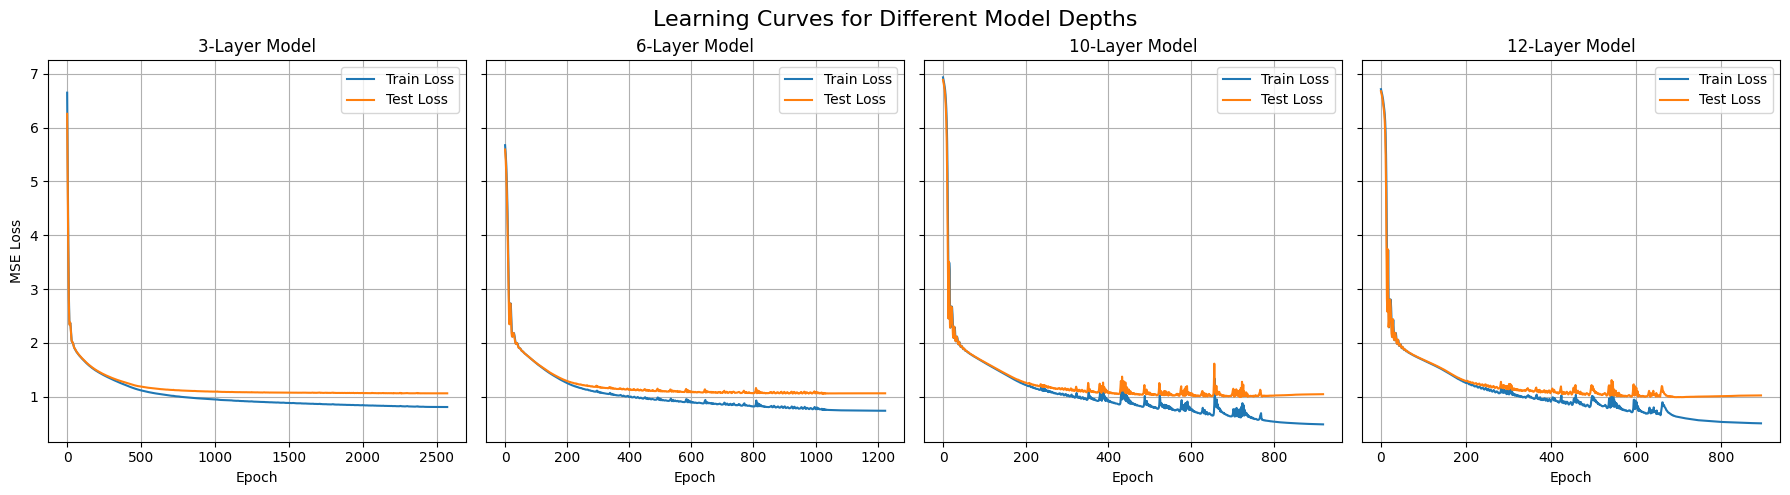

In [77]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

# Model: 3 Layers
axes[0].plot(train_losses_layers3, label="Train Loss")
axes[0].plot(test_losses_layers3, label="Test Loss")
axes[0].set_title("3-Layer Model")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True)

# Model: 6 Layers
axes[1].plot(train_losses_layers6, label="Train Loss")
axes[1].plot(test_losses_layers6, label="Test Loss")
axes[1].set_title("6-Layer Model")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

# Model: 10 Layers
axes[2].plot(train_losses_layers10, label="Train Loss")
axes[2].plot(test_losses_layers10, label="Test Loss")
axes[2].set_title("10-Layer Model")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

# Model: 12 Layers
axes[3].plot(train_losses_layers12, label="Train Loss")
axes[3].plot(test_losses_layers12, label="Test Loss")
axes[3].set_title("12-Layer Model")
axes[3].set_xlabel("Epoch")
axes[3].legend()
axes[3].grid(True)


# Set overall title
fig.suptitle("Learning Curves for Different Model Depths", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()



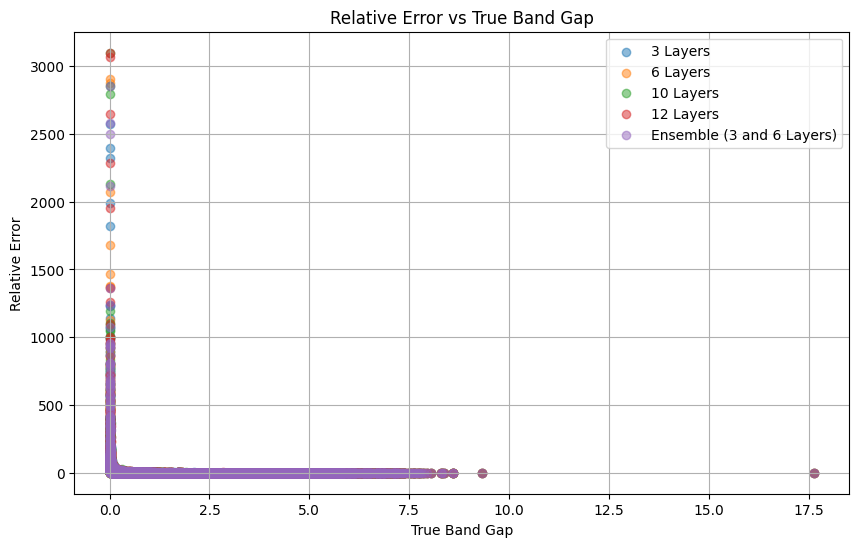

In [78]:
# relative error vs true band gap for 3 6 10 and 12 layers
plt.figure(figsize=(10, 6))
plt.scatter(y_test, np.abs(model_layers3_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5, label="3 Layers")
plt.scatter(y_test, np.abs(model_layers6_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5, label="6 Layers")
plt.scatter(y_test, np.abs(model_layers10_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5, label="10 Layers")
plt.scatter(y_test, np.abs(model_layers12_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5, label="12 Layers")
plt.scatter(y_test, np.abs(ensemble_preds.flatten() - y_test) / y_test, alpha=0.5, label="Ensemble (3 and 6 Layers)")
plt.xlabel("True Band Gap")
plt.ylabel("Relative Error")
plt.title("Relative Error vs True Band Gap")
plt.legend()
plt.grid(True)
plt.show()

# Analysis

In [ ]:
rf_model = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))
rf_model.fit(X_train, y_train)

In [82]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, np.abs(rf_model.predict(X_test) - y_test), alpha=0.5, label="Random Forest")
plt.scatter(y_test, np.abs(model_layers8_batch_leaky_metrics['test']['y_pred_test'].flatten() - y_test), alpha=0.5, label="8 Layers Leaky ReLU")
plt.xlabel("True Band Gap")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs True Band Gap")
plt.legend()
plt.grid(True)
plt.show()

IndexError: list index out of range

<Figure size 1000x600 with 0 Axes>

## Random Forest Best Model

### Shap Table

In [79]:
# Feature importance of tree based model
rf_model = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))
rf_model.fit(X_train, y_train)

importances = rf_model.named_steps["randomforestregressor"].feature_importances_

# Get feature names from the preprocessor
feature_names = rf_model.named_steps["columntransformer"].get_feature_names_out()

KeyboardInterrupt: 

In [ ]:
# Feature importance using SHAP
rf = rf_model.named_steps["randomforestregressor"]
X_transformed = rf_model.named_steps["columntransformer"].transform(X_test)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

feature_names = rf_model.named_steps["columntransformer"].get_feature_names_out()

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

In [ ]:
# Sort by importance
sorted_idx = np.argsort(importances)[::-1][:20]
top_features = np.array(feature_names)[sorted_idx]
top_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features)
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
# Using a faster SHAP explainer
rf = rf_model.named_steps["randomforestregressor"]

# Sample fewer rows for faster explanation
X_sample = X_test.sample(250, random_state=42)

# Transform using your pipeline
X_transformed = rf_model.named_steps["columntransformer"].transform(X_sample)

# Only convert if needed
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# Get feature names
feature_names = rf_model.named_steps["columntransformer"].get_feature_names_out()

# Use SHAP's auto-detect explainer (faster in new versions)
explainer = shap.Explainer(rf)

# Compute SHAP values
shap_values = explainer(X_transformed)

# Summary plot
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

## 8 Layer Leaky Relu, Batch